In [2]:
"""Imports"""
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plotting

In [3]:
"""Constants"""
TANK_RADIUS_1T_mm = 525.78
BOTTOM_PADDLE_1_CENTER = (-175, 325, -1228.05)
BOTTOM_PADDLE_2_CENTER = (-43.18, 185.42, -1228.05)
BOTTOM_PADDLE_MIDPOINT = tuple((a + b) / 2 for a, b in zip(BOTTOM_PADDLE_1_CENTER, BOTTOM_PADDLE_2_CENTER))
TOP_PADDLE_CENTER = (86,86,766.5)

# for reco simulation
TANK_TOP_Z_mm = 666.75
TANK_BOTTOM_Z_mm = -666.75

In [4]:
"""Functions"""
def find_intersection_with_z(reco_entry_xy, reco_exit_xy, z_entry, z_exit, target_z):
    """
    Extends a vector defined by two points (reco entry and exit) and finds its intersection
    with a given z-plane.

    Parameters:
        reco_entry_xy (tuple): (x, y) coordinates of the reconstructed entry point
        reco_exit_xy (tuple): (x, y) coordinates of the reconstructed exit point
        z_entry (float): z-coordinate of reco entry point (usually TANK_TOP_Z_mm)
        z_exit (float): z-coordinate of reco exit point (usually TANK_BOTTOM_Z_mm)
        target_z (float): the z-plane you want to intersect with (e.g. 766.5 or -1228.05)

    Returns:
        (x, y, target_z): the 3D point where the line intersects the target_z plane
    """
    p0 = np.array([reco_entry_xy[0], reco_entry_xy[1], z_entry], dtype=float)
    p1 = np.array([reco_exit_xy[0], reco_exit_xy[1], z_exit], dtype=float)
    direction = p1 - p0

    if direction[2] == 0:
        raise ValueError("Vector is parallel to the z-plane; no intersection.")

    t = (target_z - p0[2]) / direction[2]
    intersection = p0 + t * direction
    return tuple(intersection)

def plot_charge_vs_distance_to_track(reco_entry, reco_exit, pmt_data):
    """
    Plots PMT charge vs. distance to the reconstructed track.
    
    Parameters:
    - reco_entry: (x, y, z) tuple of reconstructed entry point
    - reco_exit: (x, y, z) tuple of reconstructed exit point
    - pmt_data: list of lists with structure [[x], [y], [z], [charge]], each of length 58
    """

    # Convert to NumPy array for easy slicing
    pmt_data = np.array(pmt_data)  # shape (58, 4)
    pmt_positions = pmt_data[:, :3]  # shape (58, 3)
    charges = pmt_data[:, 3]         # shape (58,)
    

    # Define track vector
    p0 = np.array(reco_entry)
    p1 = np.array(reco_exit)
    v = p1 - p0
    v_norm = np.linalg.norm(v)
    
    if v_norm == 0:
        raise ValueError("Reco entry and exit points are identical; cannot define a track.")
    v_hat = v / v_norm  # unit direction vector

#     # Compute distances from PMTs to the track line
#     distances = []
#     for p in pmt_positions:
# #         if p[2] < -677: # bottom PMT
# #             # color based
#         w = p - p0
#         projection = np.dot(w, v_hat) * v_hat
#         closest_point = p0 + projection
#         distance = np.linalg.norm(p - closest_point)
#         distances.append(distance)
    
#     distances = np.array(distances)
#     charges = np.array(charges)
# Compute distances from PMTs to the track line
    distances = []
    colors = []
    for p in pmt_positions:
        w = p - p0
        projection = np.dot(w, v_hat) * v_hat
        closest_point = p0 + projection
        distance = np.linalg.norm(p - closest_point)
        distances.append(distance)

        # Color based on z-coordinate
        z = p[2]
        if z == -677.1:
            colors.append('red')  # bottom PMTs
        elif z in [-495.3, -336.55]:
            colors.append('green') # bottom 2 rows
        elif z in [-211.0232, -41.1607, 128.7018]: # middle 3 rows
            colors.append('orange')
        elif z in [222.25, 393.7]: # top 2 rows
            colors.append('blue')
        else:
            colors.append('pink')  # other PMTs

    distances = np.array(distances)
    charges = np.array(charges)




    # Plot: Charge vs Distance to Track
    plt.figure(figsize=(10, 6))
    plt.scatter(distances, charges, color=colors, s=20)  # use solid color
    
    # Add legend using dummy points
    plt.scatter([], [], color='red', label='Bottom PMTs')
    plt.scatter([], [], color='green', label='Bottom 2 Rows')
    plt.scatter([], [], color='orange', label='Middle 3 Rows')
    plt.scatter([], [], color='blue', label='Top Two Rows')
    
    plt.xlabel('Distance to Track (mm)')
    plt.ylabel('Charge (pC)')
    plt.title('PMT Charge vs Distance to Reconstructed Track')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def load_data(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    return data['reco_events'], data['all_bottom_paddle_tags_for_phase']

In [5]:
fname= "/storage/group/dfc13/default/dcolson/BNL/data/infile_data4/recos/numCher_digit_weight_per/07_09_25_reco_numCher_digit_weight_per_disk_e_phase_3_1.pkl"
with open(fname, "rb") as f:
    data = pickle.load(f)
reco_events, BP_tags = load_data(fname)
# myb = 0
# for i in range(len(data)):
#     val = len(data[i]['total_charge'])
#     if val != 58:
#         myb+=1
# print(len(data))
# print(myb)

# fname = "/storage/group/dfc13/default/dcolson/my_pickles/07_09_25_processed_data_disk_e_phase_3_Weight_1.pkl"
# with open(fname, "rb") as f:
#     data = pickle.load(f)
# myb = 0
# for i in range(len(data['per_events_for_phase'])):
#     val = len(data['per_events_for_phase'][i]['total_charge'])
#     if val != 58:
#         myb+=1
# print(len(data['per_events_for_phase']))
# print(myb)

# reco_events = data['reco_events']
# bottom_paddle_tags = data['all_bottom_paddle_tags_for_phase']
# print(reco_events[0].keys())
# print(len(reco_events[9]['total_charge']))

In [6]:
bottom_PMTs_x = [381. ,  381. ,  381. ,  381. ,  190.5,  190.5,  190.5,  190.5, 190.5,  190.5,  190.5,    0. ,    0. ,    0. ,    0. ,    0. , 0. ,    0. ,    0. , -190.5, -190.5, -190.5, -190.5, -190.5, -190.5, -190.5, -381. , -381. , -381. , -381.]
bottom_PMTs_y = [-171.45,  -57.15,   57.15,  171.45, -342.9 , -228.6 , -114.3 , 0.  ,  114.3 ,  228.6 ,  342.9 , -400.05, -285.75, -171.45,-57.15,   57.15,  171.45,  285.75,  400.05, -342.9 , -228.6, -114.3 ,    0.  ,  114.3 ,  228.6 ,  342.9 , -171.45,  -57.15, 57.15,  171.45]
bottom_PMTs_z = [-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1,-677.1]

side_PMTs_x = [-532.955, -532.955, -532.955, -532.955, 532.955, 532.955, 532.955, 532.955, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
side_PMTs_y = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -532.955, -532.955, -532.955, -532.955, 532.955, 532.955, 532.955, 532.955]
side_PMTs_z = [-495.3, -336.55, 222.25, 393.7, -495.3, -336.55, 222.25, 393.7, -495.3, -336.55, 222.25, 393.7, -495.3, -336.55, 222.25, 393.7]

supp_side_PMTs_x = [-376.8561,-376.8561,-376.8561,376.8561,376.8561,376.8561,376.8561,376.8561,376.8561,-376.8561,-376.8561,-376.8561]
supp_side_PMTs_y = [-376.8561,-376.8561,-376.8561,376.8561,376.8561,376.8561,-376.8561,-376.8561,-376.8561,376.8561,376.8561,376.8561]
supp_side_PMTs_z = [-211.0232,-41.1607,128.7018,-211.0232,-41.1607,128.7018,-211.0232,-41.1607,128.7018,-211.0232,-41.1607,128.7018]

# ordered list from google slides from Sunwoo in week 2 notes
bottom_PMT_list = ['adc_b1_ch1', 'adc_b1_ch2', 'adc_b1_ch3', 'adc_b1_ch4', 'adc_b1_ch5', 'adc_b1_ch6', 'adc_b1_ch7', 'adc_b1_ch8', 'adc_b1_ch9', 'adc_b1_ch10', 'adc_b1_ch11', 'adc_b1_ch12', 'adc_b1_ch13', 'adc_b1_ch14', 'adc_b1_ch15', 'adc_b2_ch0', 'adc_b2_ch1', 'adc_b2_ch2', 'adc_b2_ch3', 'adc_b2_ch4', 'adc_b2_ch5', 'adc_b2_ch6', 'adc_b2_ch7', 'adc_b2_ch8', 'adc_b2_ch9', 'adc_b2_ch10', 'adc_b2_ch11', 'adc_b2_ch12', 'adc_b2_ch13', 'adc_b2_ch14']
side_PMT_list = ['adc_b3_ch0', 'adc_b3_ch1', 'adc_b3_ch2', 'adc_b3_ch3', 'adc_b3_ch4', 'adc_b3_ch5', 'adc_b3_ch6', 'adc_b3_ch7', 'adc_b3_ch8', 'adc_b3_ch9', 'adc_b3_ch10', 'adc_b3_ch11', 'adc_b3_ch12', 'adc_b3_ch13', 'adc_b3_ch14', 'adc_b3_ch15']
supp_side_PMT_list = ['adc_b4_ch0', 'adc_b4_ch1', 'adc_b4_ch2', 'adc_b4_ch3', 'adc_b4_ch4', 'adc_b4_ch5', 'adc_b4_ch6', 'adc_b4_ch7', 'adc_b4_ch8', 'adc_b4_ch9', 'adc_b4_ch10', 'adc_b4_ch11']

all_PMT_x_list = bottom_PMTs_x+side_PMTs_x+supp_side_PMTs_x
all_PMT_y_list = bottom_PMTs_y+side_PMTs_y+supp_side_PMTs_y
all_PMT_z_list = bottom_PMTs_z+side_PMTs_z+supp_side_PMTs_z

# list of lists [[x,y,z], ... for 58 PMTs
PMT_positions = [[all_PMT_x_list[i], all_PMT_y_list[i], all_PMT_z_list[i]] for i in range(58)] 
# wrong order or something ^

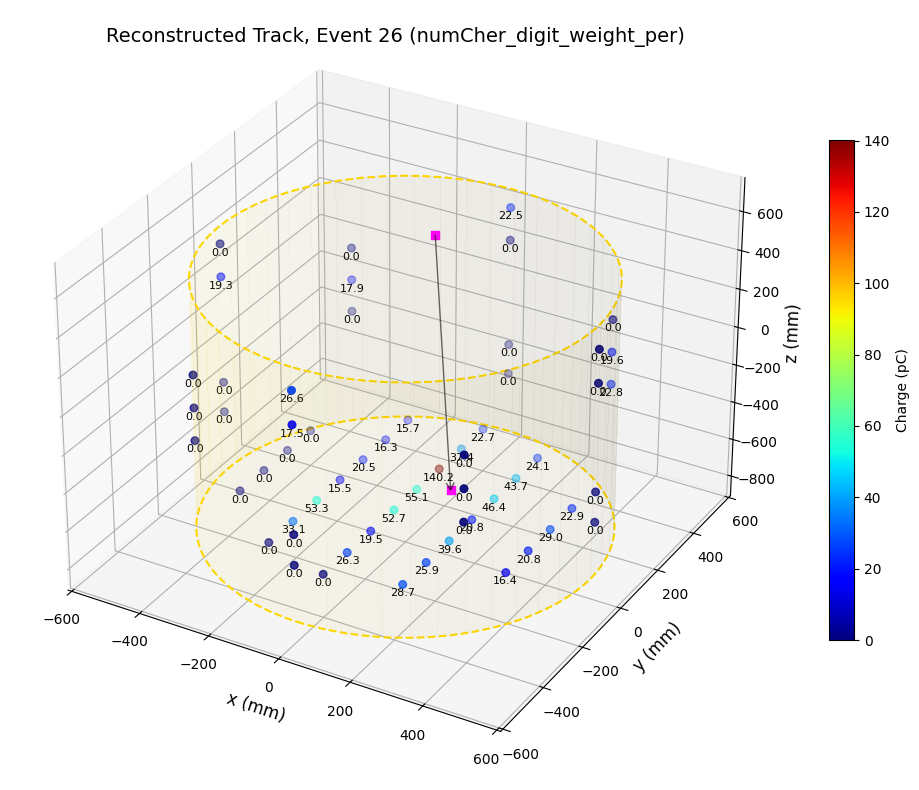

In [10]:
from mpl_toolkits.mplot3d.art3d import pathpatch_2d_to_3d
from matplotlib.patches import Circle

event_no = 26

true_entry_x, true_entry_y, true_entry_z = TOP_PADDLE_CENTER
if BP_tags[event_no] == 1:
    true_exit_x, true_exit_y, true_exit_z = BOTTOM_PADDLE_1_CENTER
elif BP_tags[event_no] == 2:
    true_exit_x, true_exit_y, true_exit_z = BOTTOM_PADDLE_2_CENTER
elif BP_tags[event_no] == 3:
    true_exit_x, true_exit_y, true_exit_z = BOTTOM_PADDLE_MIDPOINT

entry_x = reco_events[event_no]["reco"][0]
entry_y = reco_events[event_no]["reco"][1]
exit_x = reco_events[event_no]["reco"][2]
exit_y = reco_events[event_no]["reco"][3]
entry_z = 666.75
exit_z = -666.75

# Example PMT positions: replace with your actual data
# Shape: (58, 3) for x, y, z coordinates
reco_PMT_positions = [[reco_events[event_no]["total_charge"][i][0], reco_events[event_no]["total_charge"][i][1], reco_events[event_no]["total_charge"][i][2]] for i in range(58)]
pmt_positions = np.array(reco_PMT_positions)  # Replace with real PMT positions
# pmt_positions = np.array(PMT_positions)

# Simulate loading your event data
# Let's say `events` is a list of dicts, each with a `diff` key of shape (58, 6)
# For this example, I'll generate random residuals; replace with your real data

# Compute mean RMS residual per PMT
# print(reco_events[event_no]["total_charge"])
total_charge = np.array([reco_events[event_no]["total_charge"][i][3] for i in range(58)])

# Plotting
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with color based on mean residual
sc = ax.scatter(pmt_positions[:, 0], pmt_positions[:, 1], pmt_positions[:, 2],
                c=total_charge, cmap='jet', s=30)

# Add charge labels under each point
for i in range(len(pmt_positions)):
    x, y, z = pmt_positions[i]
    charge = total_charge[i]
    ax.text(x, y, z - 20, f'{charge:.1f}', fontsize=8, color='black',
            ha='center', va='top')

# Plot entry and exit points as squares
ax.scatter(entry_x, entry_y, entry_z, c='magenta', marker='s', s=30)
ax.scatter(exit_x, exit_y, exit_z, c='magenta', marker='s', s=30)

# ax.scatter(true_entry_x, true_entry_y, true_entry_z, c='pink', marker='*', s=30)
# ax.scatter(true_exit_x, true_exit_y, true_exit_z, c='pink', marker='*', s=30)

# Draw line connecting them
# ax.plot([entry_x, exit_x], [entry_y, exit_y], [entry_z, Z_EXIT], c='black', linewidth=1)

# Compute direction vector
dx = exit_x - entry_x
dy = exit_y - entry_y
dz = exit_z - entry_z

# Draw arrow
# ax.quiver(entry_x, entry_y, entry_z, dx, dy, dz, color='black', arrow_length_ratio=0.1, linewidth=2)
ax.quiver(
    entry_x, entry_y, entry_z,
    dx, dy, dz,
    color='black',
    arrow_length_ratio=0.03,
    linewidth=1,
    alpha=0.6
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.5)
cbar.set_label('Charge (pC)')
cbar.ax.set_position([0.78, 0.25, 0.02, 0.5])

# Compute bounds with padding
# padding = 50  # Adjust as needed
# x_min, x_max = pmt_positions[:, 0].min() - padding, pmt_positions[:, 0].max() + padding
# y_min, y_max = pmt_positions[:, 1].min() - padding, pmt_positions[:, 1].max() + padding
# z_min, z_max = pmt_positions[:, 2].min() - padding, pmt_positions[:, 2].max() + padding
# ax.set_xlim(x_min, x_max)
# ax.set_ylim(y_min, y_max)
# ax.set_zlim(z_min, z_max)

ax.set_xlabel('x (mm)', fontsize=12)
ax.set_ylabel('y (mm)', fontsize=12)
ax.set_zlabel('z (mm)', fontsize=12)
ax.set_title('Reconstructed Track, Event 26 (numCher_digit_weight_per)', y=1.03, fontsize=14)

###
# Parameters
r_cyl = 525
z1 = -800
z2 = 500
opacity = 0.05  # Very faint

# 1. Draw two circular bases
for z in [z1, z2]:
    circle = Circle((0, 0), r_cyl, color='gold', fill=False, linewidth=1.5, linestyle='--')
    ax.add_patch(circle)
    pathpatch_2d_to_3d(circle, z=z, zdir="z")

# 2. Draw transparent cylinder between z1 and z2
theta = np.linspace(0, 2 * np.pi, 50)
z = np.linspace(z1, z2, 2)
theta, z = np.meshgrid(theta, z)
x = r_cyl * np.cos(theta)
y = r_cyl * np.sin(theta)

ax.plot_surface(
    x, y, z,
    color='gold',
    alpha=opacity,
    linewidth=0,
    antialiased=False
)
###


# plt.show()
plt.savefig(f"/storage/group/dfc13/default/dcolson/poster_plots/persensor_detector_numCher_digit_weight_per.png", dpi=300, bbox_inches="tight")

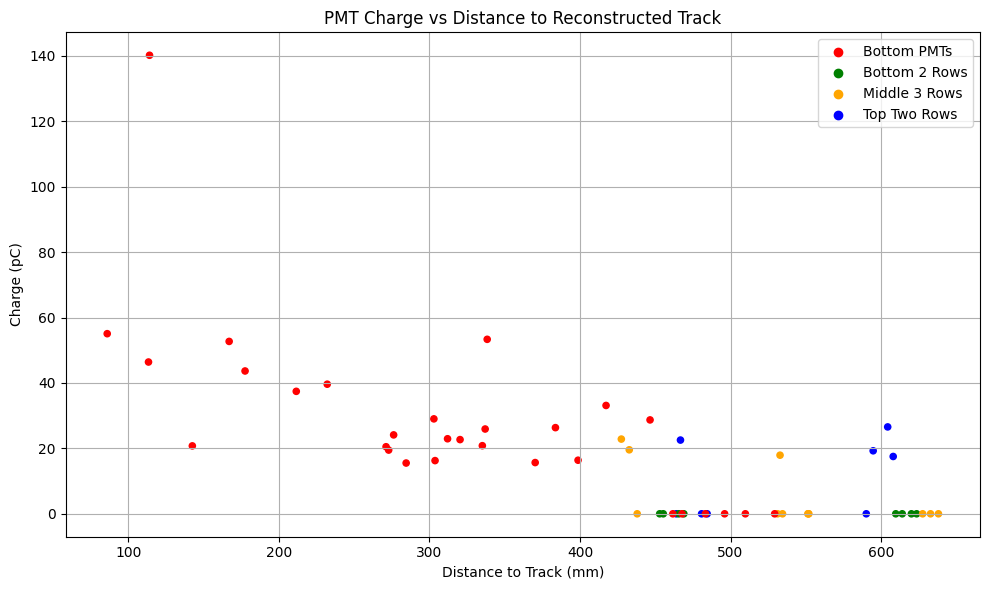

In [8]:
reco_entry = (entry_x, entry_y, entry_z)
reco_exit = (exit_x, exit_y, exit_z)
pmt_data = reco_events[event_no]["total_charge"]
plot_charge_vs_distance_to_track(reco_entry, reco_exit, pmt_data)